In [4]:
from google.colab import files
import pandas as pd
import io

print("Click 'Choose Files' and select your CSV file:")
uploaded = files.upload()

for filename in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"\n Loaded: {filename}")
    print(f"Shape: {df.shape}")

print("\nFirst 5 rows:")
df.head()

Click 'Choose Files' and select your CSV file:


Saving synthetic_data_2026-06-13.csv to synthetic_data_2026-06-13 (1).csv

 Loaded: synthetic_data_2026-06-13 (1).csv
Shape: (10000, 16)

First 5 rows:


,timestamp,bus_id,route,passenger_count,day_of_week,hour_of_day,month,day,weather_condition,distance_km,special_event,is_holiday,total_delay_minutes,scheduled_arrival_time,actual_arrival_time,traffic_intensity
0,2023-10-18T04:04:00,BUS_0000,Mexico-Piassa,19,Wednesday,4,10,18,Clear,8,NaN,False,10.647783,2023-10-18T04:28:00,2023-10-18T04:38:38.866952040,Moderate
1,2023-10-16T20:55:00,BUS_0001,Piassa-Megenagna,40,Monday,20,10,16,Clear,15,NaN,False,16.306363,2023-10-16T21:40:00,2023-10-16T21:56:18.381792972,Heavy
2,2023-02-10T18:17:00,BUS_0002,Piassa-Megenagna,71,Friday,18,2,10,Clear,15,NaN,False,34.207864,2023-02-10T19:02:00,2023-02-10T19:36:12.471810552,Severe
3,2023-03-07T10:43:00,BUS_0003,Mexico-Piassa,30,Tuesday,10,3,7,Clear,8,NaN,False,8.135201,2023-03-07T11:07:00,2023-03-07T11:15:08.112051840,Moderate
4,2023-08-18T22:29:00,BUS_0004,Mexico-Piassa,67,Friday,22,8,18,Light Rain,8,NaN,False,17.803545,2023-08-18T22:53:00,2023-08-18T23:10:48.212684286,Heavy


In [5]:
print(f"Total records: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Total records: 10,000
Columns: ['timestamp', 'bus_id', 'route', 'passenger_count', 'day_of_week', 'hour_of_day', 'month', 'day', 'weather_condition', 'distance_km', 'special_event', 'is_holiday', 'total_delay_minutes', 'scheduled_arrival_time', 'actual_arrival_time', 'traffic_intensity']

Missing values:
timestamp                    0
bus_id                       0
route                        0
passenger_count              0
day_of_week                  0
hour_of_day                  0
month                        0
day                          0
weather_condition            0
distance_km                  0
special_event             9321
is_holiday                   0
total_delay_minutes          0
scheduled_arrival_time       0
actual_arrival_time          0
traffic_intensity            0
dtype: int64


In [6]:
print("Delay Statistics:")
print(f"Mean: {df['total_delay_minutes'].mean():.2f} minutes")
print(f"Median: {df['total_delay_minutes'].median():.2f} minutes")
print(f"Max: {df['total_delay_minutes'].max():.2f} minutes")
print(f"Min: {df['total_delay_minutes'].min():.2f} minutes")

Delay Statistics:
Mean: 15.15 minutes
Median: 13.41 minutes
Max: 58.95 minutes
Min: 0.00 minutes


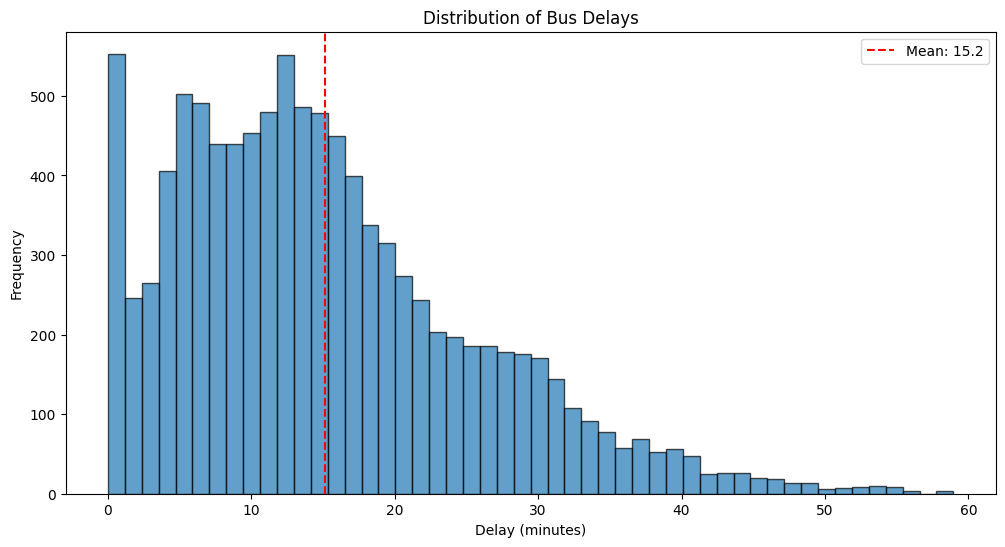

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.hist(df['total_delay_minutes'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Bus Delays')
plt.axvline(df['total_delay_minutes'].mean(), color='red', linestyle='--', label=f'Mean: {df["total_delay_minutes"].mean():.1f}')
plt.legend()
plt.show()

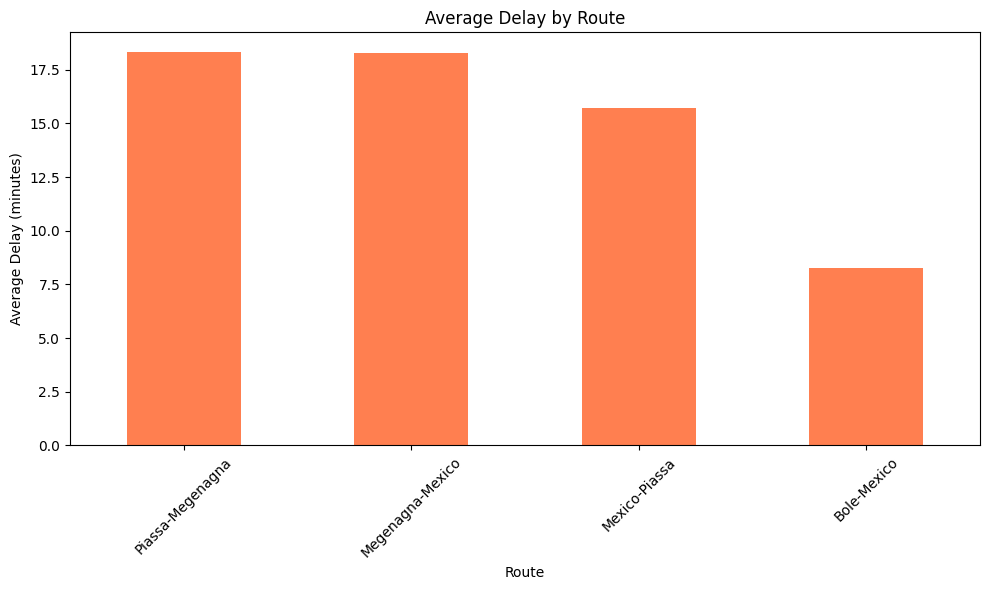


Route delays:
route
Piassa-Megenagna    18.325162
Megenagna-Mexico    18.284937
Mexico-Piassa       15.715151
Bole-Mexico          8.256091
Name: total_delay_minutes, dtype: float64


In [8]:
route_delay = df.groupby('route')['total_delay_minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
route_delay.plot(kind='bar', color='coral')
plt.xlabel('Route')
plt.ylabel('Average Delay (minutes)')
plt.title('Average Delay by Route')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nRoute delays:")
print(route_delay)

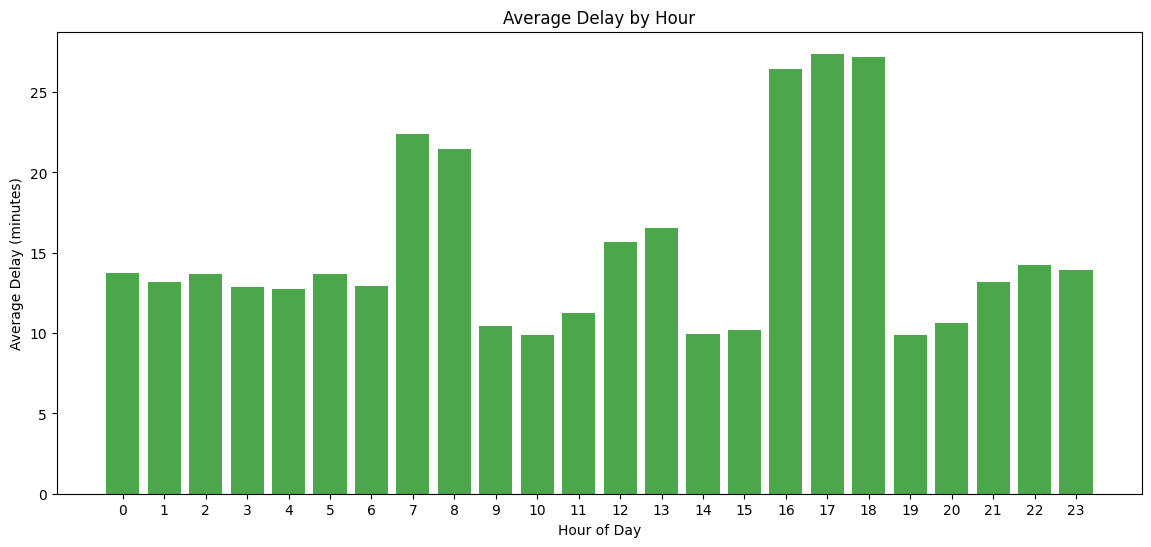

Peak hours:
hour_of_day
17    27.395229
18    27.190878
16    26.459524
7     22.376090
8     21.466167
Name: total_delay_minutes, dtype: float64


In [9]:
hour_delay = df.groupby('hour_of_day')['total_delay_minutes'].mean()

plt.figure(figsize=(14,6))
plt.bar(hour_delay.index, hour_delay.values, color='green', alpha=0.7)
plt.xlabel('Hour of Day')
plt.ylabel('Average Delay (minutes)')
plt.title('Average Delay by Hour')
plt.xticks(range(0, 24))
plt.show()

print("Peak hours:")
print(hour_delay.nlargest(5))

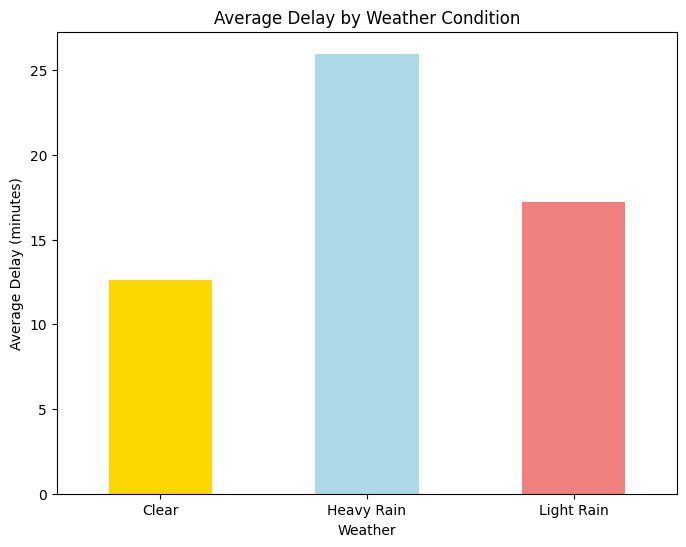

weather_condition
Clear         12.643026
Heavy Rain    25.980606
Light Rain    17.235552
Name: total_delay_minutes, dtype: float64


In [10]:
weather_delay = df.groupby('weather_condition')['total_delay_minutes'].mean()

plt.figure(figsize=(8,6))
weather_delay.plot(kind='bar', color=['gold', 'lightblue', 'lightcoral'])
plt.xlabel('Weather')
plt.ylabel('Average Delay (minutes)')
plt.title('Average Delay by Weather Condition')
plt.xticks(rotation=0)
plt.show()

print(weather_delay)

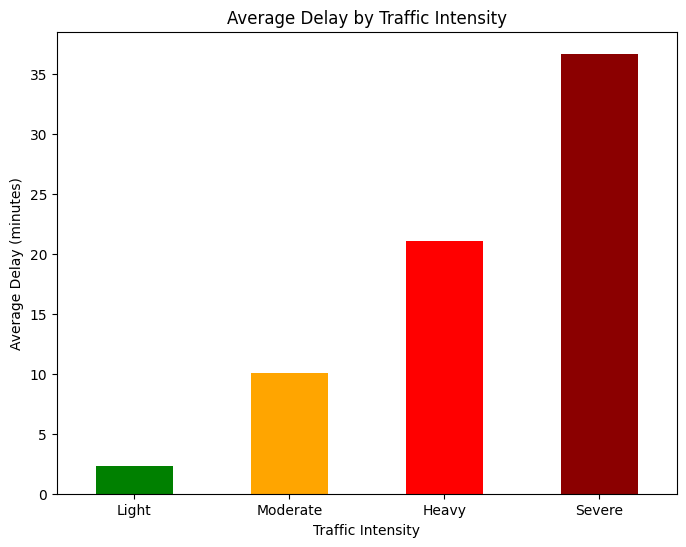

traffic_intensity
Light        2.280280
Moderate    10.048970
Heavy       21.036048
Severe      36.663901
Name: total_delay_minutes, dtype: float64


In [11]:
traffic_order = ['Light', 'Moderate', 'Heavy', 'Severe']
traffic_delay = df.groupby('traffic_intensity')['total_delay_minutes'].mean().reindex(traffic_order)

plt.figure(figsize=(8,6))
traffic_delay.plot(kind='bar', color=['green', 'orange', 'red', 'darkred'])
plt.xlabel('Traffic Intensity')
plt.ylabel('Average Delay (minutes)')
plt.title('Average Delay by Traffic Intensity')
plt.xticks(rotation=0)
plt.show()

print(traffic_delay)

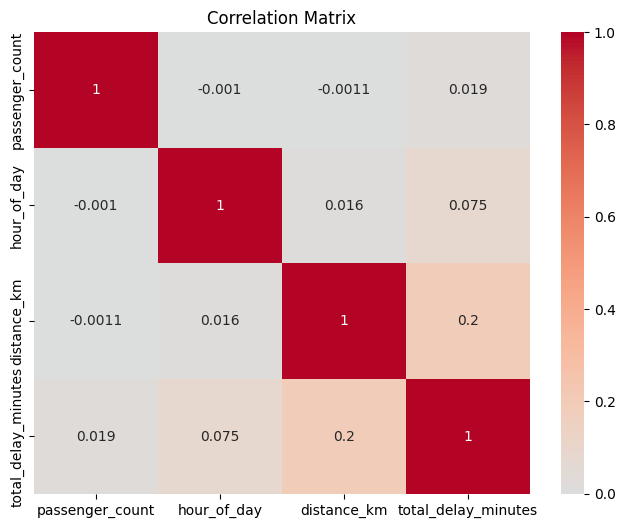


Correlations with delay:
total_delay_minutes    1.000000
distance_km            0.196554
hour_of_day            0.075169
passenger_count        0.019186
Name: total_delay_minutes, dtype: float64


In [12]:
numeric_cols = ['passenger_count', 'hour_of_day', 'distance_km', 'total_delay_minutes']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

print("\nCorrelations with delay:")
print(corr['total_delay_minutes'].sort_values(ascending=False))

Weekday avg delay: 18.14 minutes
Weekend avg delay: 7.72 minutes


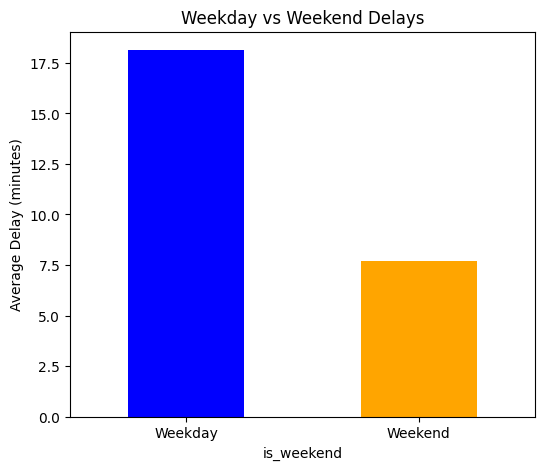

In [13]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
weekend_delay = df.groupby('is_weekend')['total_delay_minutes'].mean()

print(f"Weekday avg delay: {weekend_delay[False]:.2f} minutes")
print(f"Weekend avg delay: {weekend_delay[True]:.2f} minutes")

plt.figure(figsize=(6,5))
weekend_delay.plot(kind='bar', color=['blue', 'orange'])
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.ylabel('Average Delay (minutes)')
plt.title('Weekday vs Weekend Delays')
plt.show()